# Future Directions — What a Faithful Retry Needs

The investigation (notebook 04, `docs/FAITHFULNESS_PROBE_FINDINGS.md`,
`docs/POSTHOC_AUDITS_AND_LIMITATIONS.md`) concluded that the lightweight
baseline's ~0.55 accuracy is not distinguishable from chance. The roadmap
follow-up *experiments* — expanded population, regularization tuning,
calibration, embedding-space EDA — are walked through in notebook 04,
sections 10–12, and are not repeated here.

This notebook covers the forward-looking work that was previously only in
docs and scripts:

1. **Recovering the missing evidence text** — a working demonstration that the
   captions and surrounding context the pipeline never used are extractable
   from the `paper_path` JSONs, with live coverage numbers.
2. **Sizing the next experiment** — how many test examples a future evaluation
   needs before effects of a given size become detectable at all.
3. **The untouched half of SciVer** — the 1,500 multi-visual (sequential /
   parallel) examples this project never modeled, and what using them would
   require.
4. **A consolidated checklist** of requirements for any faithful retry.

Committed machine-readable inputs: `docs/posthoc_audit_results.json`,
`docs/faithfulness_probe_results.json`, `docs/roadmap_followup_results.json`.

## 1. Setup

Standard repo-root resolution, mirroring the other notebooks. We load the
exported pair features and the committed results files.

In [1]:
from collections import Counter
from pathlib import Path
import json
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "sciver_vector_db").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT))

RAW_ROOT = REPO_ROOT / "data/raw/SciVer"
PAPERS_DIR = RAW_ROOT / "papers"

df = pd.read_parquet(REPO_ROOT / "data/processed/sciver_pair_features.parquet")
audit_results = json.loads((REPO_ROOT / "docs/posthoc_audit_results.json").read_text())
probe_results = json.loads((REPO_ROOT / "docs/faithfulness_probe_results.json").read_text())

direct_chart = df[(df["modality"] == "chart") & (df["claim_type"] == "direct")].reset_index(drop=True)
print(f"Pairs: {len(df):,} total, {len(direct_chart)} direct+chart.")

Pairs: 1,500 total, 416 direct+chart.


## 2. Recovering the Missing Evidence

The central root-cause finding: `evidence_text_vec` was the embedding of an
empty string for all 1,500 pairs, because captions and context live in the
per-paper JSONs (`paper_path`) that the parser never opened. The post-hoc
audit established recoverability in aggregate (captions for 83% of pairs,
related-sentence context for 78%). Here we actually extract them, using the
same filename-to-entry mapping as `scripts/posthoc_audits.py`: figures resolve
via `image_paths[n].caption`, tables via `tables[n].capture`, and surrounding
context via `image_result`/`table_result` → `related_sentences_ids` into the
section list.

In [2]:
FIGURE_RE = re.compile(r"_figure_(\d+)\.")
TABLE_RE = re.compile(r"-Table(\d+)-")

_paper_cache = {}

def load_paper(paperid):
    if paperid not in _paper_cache:
        path = PAPERS_DIR / f"{paperid}.json"
        try:
            _paper_cache[paperid] = json.loads(path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            _paper_cache[paperid] = None
    return _paper_cache[paperid]

def recover_evidence(paperid, image_path):
    """Return (caption, [(section_name, section_text), ...]) for one pair, or (None, [])."""
    paper = load_paper(paperid)
    if paper is None:
        return None, []
    name = Path(str(image_path)).name
    caption, context_key = None, None
    if m := FIGURE_RE.search(name):
        caption = ((paper.get("image_paths") or {}).get(m.group(1)) or {}).get("caption")
        context_key = ("image_result", m.group(1))
    elif m := TABLE_RE.search(name):
        caption = ((paper.get("tables") or {}).get(m.group(1)) or {}).get("capture")
        context_key = ("table_result", m.group(1))
    sections = []
    if context_key is not None:
        section_map = (paper.get(context_key[0]) or {}).get(context_key[1]) or {}
        by_id = {s.get("section_id"): s for s in (paper.get("sections") or [])}
        for sec_id, entry in section_map.items():
            if (entry or {}).get("related_sentences_ids") and sec_id in by_id:
                sec = by_id[sec_id]
                sections.append((sec.get("section_name", sec_id), sec.get("text", "")))
    return caption, sections

# Demonstrate on the first three direct+chart pairs whose caption resolves.
# (Not every filename matches the figure/table patterns -- coverage is
# quantified honestly in the next cell.)
shown = 0
for _, row in direct_chart.iterrows():
    caption, sections = recover_evidence(row["paperid"], row["image_path"])
    if not (caption and str(caption).strip()):
        continue
    print("=" * 100)
    print(f"CLAIM ({row['label']}): {row['claim'][:180]}")
    print(f"CAPTION (never used by the pipeline): {str(caption)[:200]}")
    for name, text in sections[:1]:
        print(f"RELATED SECTION [{name}]: {text[:220]}...")
    shown += 1
    if shown == 3:
        break

CLAIM (entailed): The first auxiliary limit state surface G(3u)=42.23 (green) lies about twice as close to the origin (approximately 2 units along u1) compared to the true failure surface G(u)=0 (bl
CAPTION (never used by the pipeline): Figure 6:  Samples, important directions and intermediate LSFs of SDIS in standard normal sapce in problem 4.1.
RELATED SECTION [ Two-dimensional example with multiple failure domains]: In this example, we investigate the performance of the enhanced SDIS with the two-dimensional LSF adapted from [27  ###reference_b27###]:
where  and  are independent normal random variables with zero mean and standard de...
CLAIM (refuted): In the two-component mixture (first two panels), the tempered distribution Qᵅ shows two distinct sharp peaks at around ±1, matching the original X which is nearly uniform across th
CAPTION (never used by the pipeline): Figure 3: Tempered distributions of pXsubscript𝑝𝑋p_{X}italic_p start_POSTSUBSCRIPT italic_X end_POSTSUBSCRIPT: the fi

Each of these captions and section excerpts is exactly the evidence a
claim-checker needs — and none of it ever reached the model. Now the live
coverage over the full direct+chart subset:

Direct+chart pairs with a real caption:        294 / 416 (71%)
Direct+chart pairs with related-section text:  270 / 416 (65%)
All-pairs coverage from the committed audit:   1245/1500 captions, 1177/1500 context


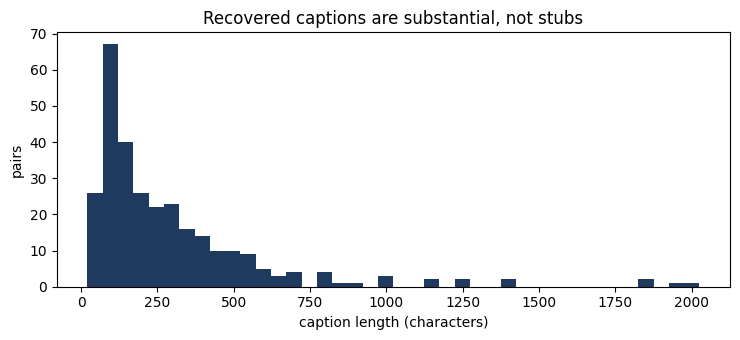

In [3]:
rows = []
for _, row in direct_chart.iterrows():
    caption, sections = recover_evidence(row["paperid"], row["image_path"])
    rows.append({
        "has_caption": bool(caption and str(caption).strip()),
        "caption_chars": len(str(caption)) if caption and str(caption).strip() else 0,
        "has_context": bool(sections),
    })
cov = pd.DataFrame(rows)
print(f"Direct+chart pairs with a real caption:        {cov['has_caption'].sum()} / {len(cov)} "
      f"({cov['has_caption'].mean():.0%})")
print(f"Direct+chart pairs with related-section text:  {cov['has_context'].sum()} / {len(cov)} "
      f"({cov['has_context'].mean():.0%})")
print(f"All-pairs coverage from the committed audit:   "
      f"{audit_results['caption_recoverability']['caption_nonempty']}/1500 captions, "
      f"{audit_results['caption_recoverability']['related_context_found']}/1500 context")

plt.figure(figsize=(7.5, 3.5))
plt.hist(cov.loc[cov["has_caption"], "caption_chars"], bins=40, color="#1F3A5F")
plt.xlabel("caption length (characters)")
plt.ylabel("pairs")
plt.title("Recovered captions are substantial, not stubs")
plt.tight_layout()
plt.show()

Coverage on this subset (71% captions / 65% context) is lower than the
all-pairs figures (83% / 78%): some chart image paths are content-addressed
blob filenames that the figure/table filename patterns cannot resolve. Both
numbers are **lower bounds** — the audit notes the remainder are mostly
filename-pattern variants a more complete resolver could map.

**What this enables.** A parser extension that populates
`evidence_text_vec` with caption + related-sentence context turns the dead
claim-vs-evidence interaction features (notebook 02) into real comparisons.
This is the single highest-priority fix: without it, the task is undecidable
by construction.

## 3. Sizing the Next Experiment

The headline experiment evaluated on 276 test examples, where the minimum
detectable effect (vs 0.50, 80% power) is ~7.5 accuracy points — larger than
any plausible edge a lightweight model would have. Statistical power must be a
design input next time, not an afterthought. The curve below uses the same
normal-approximation formula as `scripts/posthoc_audits.py`, with the
two-sided variant now standard for this project (under-performance counts as
evidence of a problem too).

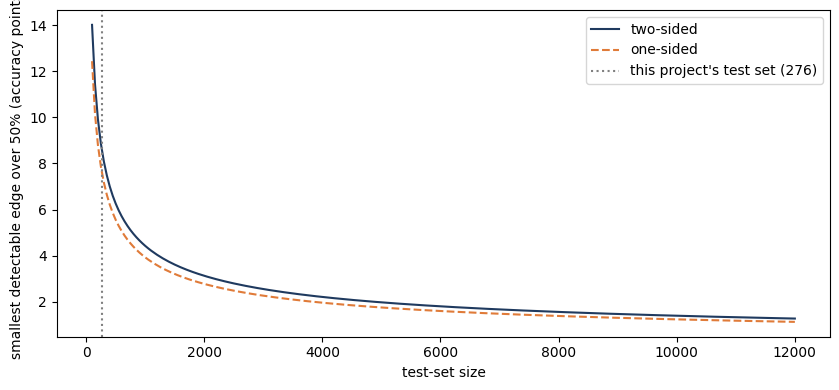

,target edge (points),n needed (two-sided),n needed (one-sided)
0,2.0,4906,3865
1,3.0,2181,1718
2,5.0,785,619
3,7.5,349,275


Sanity check vs committed audit (n=276, two-sided): 0.584 ≈ 0.584


In [4]:
def mde(n, alpha=0.05, sided=2, power=0.80):
    """Minimum detectable accuracy vs 0.5 (normal approximation)."""
    z_alpha = norm.ppf(1 - alpha / sided)
    z_power = norm.ppf(power)
    return 0.5 + (z_alpha + z_power) * np.sqrt(0.25 / n)

def n_needed(effect_points, alpha=0.05, sided=2, power=0.80):
    """Test-set size needed to detect a given accuracy edge (in points)."""
    z = norm.ppf(1 - alpha / sided) + norm.ppf(power)
    return int(np.ceil((z * 0.5 / (effect_points / 100)) ** 2))

ns = np.arange(100, 12001, 50)
plt.figure(figsize=(8.5, 4))
plt.plot(ns, [(mde(n) - 0.5) * 100 for n in ns], color="#1F3A5F", label="two-sided")
plt.plot(ns, [(mde(n, sided=1) - 0.5) * 100 for n in ns], color="#E07B39", ls="--", label="one-sided")
plt.axvline(276, color="gray", ls=":", label="this project's test set (276)")
plt.xlabel("test-set size")
plt.ylabel("smallest detectable edge over 50% (accuracy points)")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.DataFrame({
    "target edge (points)": [2, 3, 5, 7.5],
    "n needed (two-sided)": [n_needed(e) for e in (2, 3, 5, 7.5)],
    "n needed (one-sided)": [n_needed(e, sided=1) for e in (2, 3, 5, 7.5)],
})
display(table)
print("Sanity check vs committed audit (n=276, two-sided):",
      audit_results["analytic_power_min_detectable_accuracy"]["n_276"]["two_sided_alpha_05"],
      f"≈ {mde(276):.3f}")

Reading the table: to credibly detect a realistic 2–3 point edge, a
future evaluation needs a test set in the thousands — the full 1,500-pair
single-visual set is barely enough for 4-point effects, and the 276-example
subset was never going to support fine distinctions. Two further design rules
from the audits: split **grouped by paper** (labels cluster within papers,
perm p = 0.002, and embeddings encode paper identity), and **image-aware**
splits for all-pairs work (48 images carry both labels; a leaky split gives a
deterministic 0.968 ceiling to exploit).

## 4. The Untouched Half of SciVer

This project used only the single-visual subsets (`direct`, `analytical`):
one claim, one chart or table. SciVer's other two subsets require reasoning
over **two** visuals and were skipped entirely by the `single_visual_only`
pair builder.

In [5]:
counts = Counter()
for split_name in ("valset", "testset"):
    rows = json.loads((RAW_ROOT / f"{split_name}.json").read_text())
    if isinstance(rows, dict):
        rows = list(rows.values())
    for r in rows:
        counts[(r.get("claim_type"), "multi" if not r.get("item") else "single")] += 1

summary = pd.DataFrame(
    [{"claim_type": ct, "evidence": ev, "examples": n} for (ct, ev), n in sorted(counts.items())]
)
display(summary)
print(f"Single-visual examples (modeled): {summary.loc[summary.evidence == 'single', 'examples'].sum():,}")
print(f"Multi-visual examples (untouched): {summary.loc[summary.evidence == 'multi', 'examples'].sum():,}")

,claim_type,evidence,examples
0,analytical,single,750
1,direct,single,750
2,parallel,multi,750
3,sequential,multi,750


Single-visual examples (modeled): 1,500
Multi-visual examples (untouched): 1,500


Using the sequential/parallel half would require a different pair
structure (one claim linked to `item1` **and** `item2`, each with its own
image and caption) and a model input that can hold two visuals — but it would
double the data and unlock the subsets where evidence synthesis, not value
lookup, is the skill being tested.

## 5. Consolidated Checklist for a Faithful Retry

Ordered by priority; sources in parentheses.

1. **Wire the recovered evidence in.** Populate `evidence_text_vec` with
   caption + related-section context (section 2 above; coverage 83%/78%).
   Without this the task is undecidable by construction.
2. **Replace the image encoder.** CLIP-base encodes style/paper identity, not
   chart values (notebook 04 §12). Use a chart-native encoder and/or OCR the
   figures.
3. **Size the experiment first.** Pick the effect size that matters, read the
   required n off section 3's table; report two-sided permutation results with
   full null distributions (now the default in `scripts/faithfulness_probe.py`
   and `scripts/posthoc_audits.py`).
4. **Group every split by paper** and keep splits image-aware on all-pairs
   populations (audits 1–2).
5. **Check calibration, not just accuracy** — the old baseline was
   anti-calibrated (Brier 0.431 vs 0.25 for always-0.5; notebook 04 §11).
6. **Consider the multi-visual half** (section 4) once the single-visual
   pipeline is sound.
7. **Alternative pivot:** the dataset, parser, embeddings, and statistical
   machinery transfer directly to difficulty-modeling / confidence-metric work
   over multiple models (`docs/POSTHOC_AUDITS_AND_LIMITATIONS.md`,
   "Implications for future directions").